In [2]:
from pathlib import Path
import sys
import importlib

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "powerflow_plotting.py").exists():
    PLOTTING_DIR = NOTEBOOK_DIR
else:
    PLOTTING_DIR = Path("GridExpand/5.postprocessing/plotting").resolve()

if str(PLOTTING_DIR) not in sys.path:
    sys.path.insert(0, str(PLOTTING_DIR))

import powerflow_plotting
importlib.reload(powerflow_plotting)

from powerflow_plotting import (
    load_powerflow_comparison_data,
    powerflow_comparison_grid_count_summary,
    powerflow_distribution_similarity_summary,
    plot_powerflow_asset_cutoff_overview,
    plot_powerflow_asset_cutoff_overview_static,
    save_plotly_figure,
)


In [3]:
PLZ = 91301
STAGE = "pre"
SYNTHETIC_RUN_NAME = "3_synthetic"
REAL_RUN_NAME = "real_hybrid"
COLORS = {
    "Synthetic": "#335C81",
    "Real SWF": "#D95D39",
}
FILTER_NON_CONVERGED_GRIDS = False
MIN_SELECTED_HH_BUSES = 10


In [4]:
comparison_data = load_powerflow_comparison_data(
    plz=PLZ,
    synthetic_run_name=SYNTHETIC_RUN_NAME,
    real_run_name=REAL_RUN_NAME,
    stage=STAGE,
    min_selected_household_buses=MIN_SELECTED_HH_BUSES,
    filter_non_converged_grids=FILTER_NON_CONVERGED_GRIDS,
)

summary_all = comparison_data["summary_all"]
summary = comparison_data["summary"]
synthetic_summary = comparison_data["synthetic_summary"]
real_summary = comparison_data["real_summary"]
percentile_profile_all = comparison_data["percentile_profile_all"]
percentile_profile = comparison_data["percentile_profile"]
scope_filter_overview = comparison_data["scope_filter_overview"]
filtered_grids = comparison_data["filtered_grids"]
convergence_overview = comparison_data["convergence_overview"]
coverage = comparison_data["coverage"]


In [5]:
grid_count_summary = powerflow_comparison_grid_count_summary(
    plz=PLZ,
    synthetic_run_name=SYNTHETIC_RUN_NAME,
    real_run_name=REAL_RUN_NAME,
    stage=STAGE,
    scope_filter_overview=scope_filter_overview,
    coverage=coverage,
)
grid_count_summary


,comparison_group,run_name,launched_powerflow_runs,powerflow_summary_grids,hard_failed_runs_without_summary,criterion,grids_removed_by_filter,powerflow_grids_after_filter,voltage_assets_after_filter,cable_assets_after_filter
0,Synthetic,3_synthetic,90,79,11,selected_household_load_buses >= 10,10,69,5738,7740
1,Real SWF,real_hybrid,102,93,9,selected_household_load_buses >= 10,23,70,5939,7944


In [6]:
similarity_summary = powerflow_distribution_similarity_summary(percentile_profile)
similarity_summary


,metric,median_diff,std,wasserstein
0,Transformer,6.499122,-10.952610,8.008580
1,Cables,4.412275,-5.323205,5.326674
2,Voltage,0.004550,-0.035099,0.022362


In [12]:
asset_cutoff_overview_fig = plot_powerflow_asset_cutoff_overview(
    percentile_profile,
    group_col="comparison_group",
    color_map=COLORS,
    asset_cutoff_percentiles=(1.0, 0.99, 0.95, 0.90),
    y_axis_limits=(80, 80, 0.6),
    center_stat="mean",  # "median" or "mean"
    show_band=True,
    worst_asset_per_grid=True,
    title=f"Synthetic vs Real SWF - Retained Asset Cutoff Overview - PLZ {PLZ}",
)


In [8]:
OUTPUT_DIR = PLOTTING_DIR / "output"
saved_asset_percentile_paths = save_plotly_figure(
    asset_cutoff_overview_fig,
    OUTPUT_DIR / "asset-percentiles",
    formats=("png", "svg"),
    width=1500,
    height=860,
    scale=2.0,
    active_slider_step="Show cutoffs through P95",
)
saved_asset_percentile_paths


[PosixPath('/home/breveron/git/github/SurroGrid/GridExpand/5.postprocessing/plotting/output/asset-percentiles.png'),
 PosixPath('/home/breveron/git/github/SurroGrid/GridExpand/5.postprocessing/plotting/output/asset-percentiles.svg')]

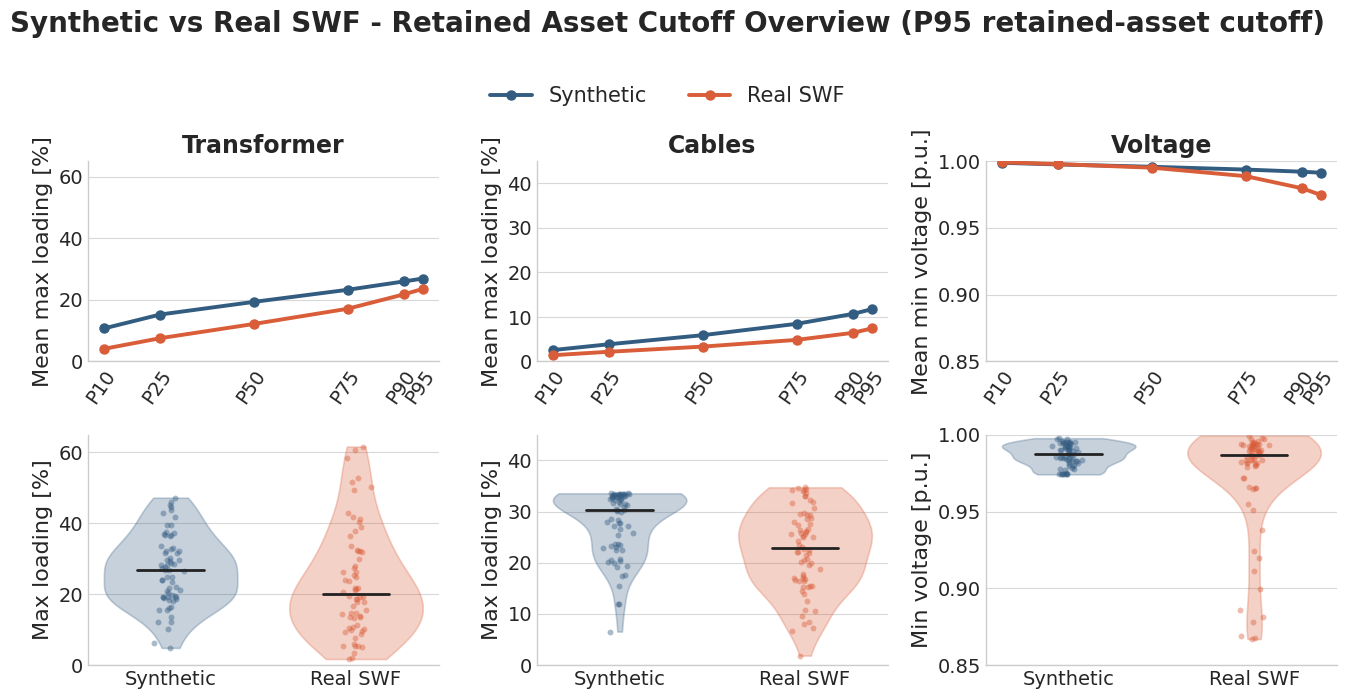

In [9]:
OUTPUT_DIR = PLOTTING_DIR / "output"
static_asset_cutoff_overview_fig = plot_powerflow_asset_cutoff_overview_static(
    percentile_profile,
    group_col="comparison_group",
    color_map=COLORS,
    asset_cutoff_percentile=0.95,
    y_axis_limits=(65, 45, 0.85),
    center_stat="mean",
    show_band=False,
    worst_asset_per_grid=True,
    title="Synthetic vs Real SWF - Retained Asset Cutoff Overview",
    save_path=OUTPUT_DIR / "asset-percentiles-static",
    save_formats=("svg", "pdf"),
)
